In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer      
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_auc_score,auc

In [2]:
df = pd.read_csv('spam_ham_dataset.csv')

In [ ]:
print(df.columns)
print(df.isna().sum())

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64


In [ ]:

# Force clean labels
df["label"] = df["label"].astype(str).str.strip().str.lower()

# Map to numeric
df["label_binary"] = df["label"].map({"ham": 0, "spam": 1})

# Check mapping worked
print(df["label_binary"].unique())   # MUST show [0 1]

# Use ONLY numeric labels
X = df["text"]
y = df["label_binary"]   # <--- IMPORTANT


[0 1]


In [ ]:


# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 4. Vectorizer
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# 5. Model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# 6. Evaluate
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9864734299516909

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       742
           1       0.97      0.98      0.98       293

    accuracy                           0.99      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.99      0.99      0.99      1035



In [ ]:
# 7. Try a prediction
sample = ["You won $10,000! Claim your prize now."]
sample_tfidf = tfidf.transform(sample)
print("\nSample Prediction:", model.predict(sample_tfidf)[0])


Sample Prediction: 0


Confusion Matrix:
 [[734   8]
 [  6 287]]


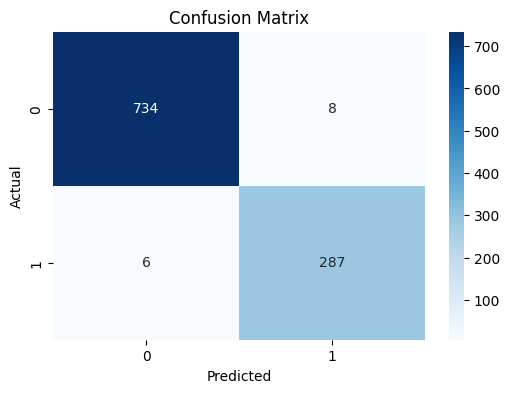

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

AUC Score: 0.9983717100723991


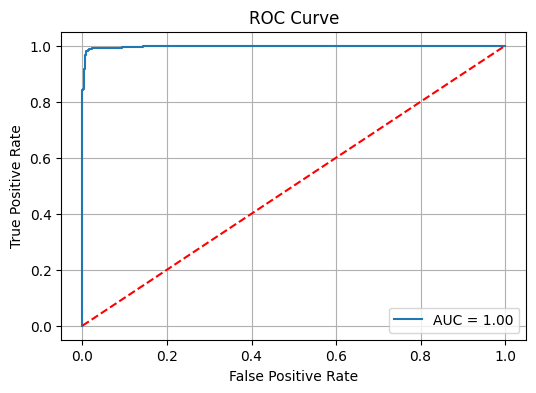

In [ ]:
# ------------------------------------------
# ROC Curve & AUC
# ------------------------------------------
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "r--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()